In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


## Import Library

In [2]:
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Load Datasets

In [3]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [4]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [5]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 32 40
- High-res shape : 128 160

In [6]:
# =========================================
# Truth is the constraint — fit forecast to it
# =========================================
scale = 6

ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [7]:
ds_fc

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 32, latitude: 24)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 684MB ...

In [8]:
ds_tr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      46848 | 0.02738%
10m_v_component_of_wind        | NaNs:      46848 | 0.02738%
2m_temperature                 | NaNs:      46848 | 0.02738%
total_precipitation_24hr       | NaNs:   11262720 | 6.58296%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [10]:
def count_nan_per_time(ds, var):
    data = ds[var]

    spatial_dims = [d for d in data.dims if d != "time"]

    nan_count = data.isnull().sum(dim=spatial_dims)

    result = nan_count.to_dataframe(name="nan_count")
    result = result[result["nan_count"] > 0]

    print(result.head(20))

    return result

nan_summary = count_nan_per_time(ds_fc, "10m_u_component_of_wind")

# Get worst timestep (most NaNs)
worst_time = nan_summary["nan_count"].idxmax()

print("Worst timestep:", worst_time)

sample = ds_fc["10m_u_component_of_wind"].sel(time=worst_time)

print(sample)

            nan_count
time                 
2019-10-17      46848
Worst timestep: 2019-10-17 00:00:00
<xarray.DataArray '10m_u_component_of_wind' (prediction_timedelta: 61,
                                             longitude: 32, latitude: 24)> Size: 187kB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 488B 00:00:0..

#### Drop lead 0
because total precipitation in lead 0 is nan

In [11]:
ds_fc = ds_fc.sel(prediction_timedelta=slice(np.timedelta64(1,'D'), None))

In [12]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      43776 | 0.02738%
10m_v_component_of_wind        | NaNs:      43776 | 0.02738%
2m_temperature                 | NaNs:      43776 | 0.02738%
total_precipitation_24hr       | NaNs:      43776 | 0.02738%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [13]:
def check_fully_missing_timesteps(ds, name):
    print(f"\n==== Fully Missing Timesteps: {name} ====")
    for var in ds.data_vars:
        data = ds[var]
        # Collapse spatial dims
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)
        n_missing = missing_time.sum().item()
        print(f"{var:30s} | fully-missing timesteps: {n_missing}")

check_fully_missing_timesteps(ds_fc, "Forecast")
check_fully_missing_timesteps(ds_tr, "Truth")


==== Fully Missing Timesteps: Forecast ====
10m_u_component_of_wind        | fully-missing timesteps: 1
10m_v_component_of_wind        | fully-missing timesteps: 1
2m_temperature                 | fully-missing timesteps: 1
total_precipitation_24hr       | fully-missing timesteps: 1

==== Fully Missing Timesteps: Truth ====
10m_u_component_of_wind        | fully-missing timesteps: 0
10m_v_component_of_wind        | fully-missing timesteps: 0
2m_temperature                 | fully-missing timesteps: 0
total_precipitation_24hr       | fully-missing timesteps: 0


In [14]:
def find_missing_timesteps(ds):
    for var in ds.data_vars:
        data = ds[var]
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)

        missing_times = ds.time.where(missing_time, drop=True)

        print(f"\nVariable: {var}")
        print("Missing times:")
        print(missing_times.values)

find_missing_timesteps(ds_fc)


Variable: 10m_u_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 10m_v_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 2m_temperature
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: total_precipitation_24hr
Missing times:
['2019-10-17T00:00:00.000000000']


In [15]:
missing_time = np.datetime64("2019-10-17T00:00:00")

# Drop from forecast
ds_fc = ds_fc.drop_sel(time=missing_time)

# Drop from truth (important to keep alignment)
ds_tr = ds_tr.drop_sel(time=missing_time)

In [16]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Temporal Allignment data

In [17]:
# ==============================
# CONFIG
# ==============================
lead_days = 5
lead_td = np.timedelta64(lead_days, "D")

# ==============================
# 1️⃣ Lead selection
# ==============================
ds_fc_lead = ds_fc.sel(prediction_timedelta=lead_td)

# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc_lead.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc_lead = ds_fc_lead.assign_coords(valid_time=valid_time)
ds_fc_lead = ds_fc_lead.sel(valid_time=common_times)
ds_fc_lead = ds_fc_lead.assign_coords(time=ds_fc_lead.valid_time)
ds_fc_lead = ds_fc_lead.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc_lead.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc_lead.time),
      len(ds_fc_lead.latitude),
      len(ds_fc_lead.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3640
Forecast time == Truth time: True
Forecast shape: 3640 24 32
Truth shape: 3640 144 192


## Data model preparation

In [18]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1️⃣ Variable stacking
# ==========================================
vars_list = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_fc_lead[v].values for v in vars_list],
    axis=1
)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr_aligned[v].values for v in vars_list],
    axis=1
)

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2️⃣ Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

# ==========================================
# 3️⃣ Train / Val / Test split (80 / 10 / 10)
#    Split BEFORE normalization!
#    Keep temporal order — no shuffle
# ==========================================
N = X.shape[0]
train_end = int(0.8 * N)
val_end   = int(0.9 * N)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

Y_train = Y[:train_end]
Y_val   = Y[train_end:val_end]
Y_test  = Y[val_end:]

print(f"\nSplit sizes (N={N}):")
print(f"  Train : {len(X_train)} ({len(X_train)/N*100:.1f}%)")
print(f"  Val   : {len(X_val)}   ({len(X_val)/N*100:.1f}%)")
print(f"  Test  : {len(X_test)}  ({len(X_test)/N*100:.1f}%)")

# ==========================================
# 4️⃣ Normalization — train stats only!
#    Per-channel normalization
# ==========================================
# Shape: (1, C, 1, 1) for broadcasting
mean = X_train.mean(axis=(0, 2, 3), keepdims=True)  # (1, 4, 1, 1)
std  = X_train.std(axis=(0, 2, 3),  keepdims=True)  # (1, 4, 1, 1)

X_train = (X_train - mean) / (std + 1e-6)
X_val   = (X_val   - mean) / (std + 1e-6)
X_test  = (X_test  - mean) / (std + 1e-6)

# ⚠️ Y uses SAME per-channel stats as X (same variables)
# so denormalization at inference is consistent
Y_train = (Y_train - mean) / (std + 1e-6)
Y_val   = (Y_val   - mean) / (std + 1e-6)
Y_test  = (Y_test  - mean) / (std + 1e-6)

# Save stats for denormalization at inference
norm_stats = {
    "mean": torch.tensor(mean, dtype=torch.float32),
    "std" : torch.tensor(std,  dtype=torch.float32),
}
print("\nNorm stats per channel:")
for i, v in enumerate(vars_list):
    print(f"  {v}: mean={mean[0,i,0,0]:.4f}, std={std[0,i,0,0]:.4f}")

# ==========================================
# 5️⃣ Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6️⃣ DataLoaders
# ==========================================
BATCH_SIZE = 16

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,   # shuffle only train
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7️⃣ Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, norm_stats):
    """Reverse normalization for interpretable outputs."""
    mean = norm_stats["mean"].to(tensor.device)
    std  = norm_stats["std"].to(tensor.device)
    return tensor * (std + 1e-6) + mean

Before axis check:
X shape: (3640, 4, 32, 24)
Y shape: (3640, 4, 144, 192)
Y axes corrected
Corrected shapes:
X: (3640, 4, 32, 24)
Y: (3640, 4, 192, 144)

Split sizes (N=3640):
  Train : 2912 (80.0%)
  Val   : 364   (10.0%)
  Test  : 364  (10.0%)

Norm stats per channel:
  10m_u_component_of_wind: mean=-1.4961, std=3.9220
  10m_v_component_of_wind: mean=0.4607, std=2.9133
  2m_temperature: mean=299.7101, std=2.1155
  total_precipitation_24hr: mean=0.0062, std=0.0063

Final tensor shapes:
  X_train : torch.Size([2912, 4, 32, 24])
  Y_train : torch.Size([2912, 4, 192, 144])
  X_val   : torch.Size([364, 4, 32, 24])
  Y_val   : torch.Size([364, 4, 192, 144])
  X_test  : torch.Size([364, 4, 32, 24])
  Y_test  : torch.Size([364, 4, 192, 144])

DataLoaders ready:
  Train batches : 182
  Val batches   : 23
  Test batches  : 23


In [19]:
print("Scale H:", Y_train.shape[2] / X_train.shape[2])
print("Scale W:", Y_train.shape[3] / X_train.shape[3])

Scale H: 6.0
Scale W: 6.0


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# Building Blocks
# ==========================================

class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """MaxPool → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    """Upsample → concat skip → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if spatial dims mismatch
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        x  = F.pad(x, [dx // 2, dx - dx // 2,
                        dy // 2, dy - dy // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UpscaleBlock(nn.Module):
    """
    6× upscale via three 2× bilinear steps + refinement conv.
    Input  : (B, C, 24, 32)   — low-res encoder output
    Output : (B, C, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up1   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch,      in_ch // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 2),
            nn.ReLU(inplace=True),
        )
        self.up2   = nn.Sequential(
            nn.Upsample(scale_factor=3, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch // 2, in_ch // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 4),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Conv2d(in_ch // 4, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.up1(x)    # (B, C//2, 48,  64)
        x = self.up2(x)    # (B, C//4, 144, 192)
        return self.refine(x)


# ==========================================
# U-Net + 6× Super-Resolution Head
# ==========================================

class SRUNet(nn.Module):
    """
    Input  : (B, 4, 24, 32)   — low-res forecast
    Output : (B, 4, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch=4, out_ch=4, base_ch=64):
        super().__init__()

        # ── Encoder ──────────────────────────────
        self.enc1 = DoubleConv(in_ch,       base_ch)      # (B, 64,  24, 32)
        self.enc2 = Down(base_ch,           base_ch * 2)  # (B, 128, 12, 16)
        self.enc3 = Down(base_ch * 2,       base_ch * 4)  # (B, 256,  6,  8)

        # ── Bottleneck ───────────────────────────
        self.bottleneck = Down(base_ch * 4, base_ch * 8)  # (B, 512,  3,  4)

        # ── Decoder ──────────────────────────────
        self.dec3 = Up(base_ch * 8,  base_ch * 4)         # (B, 256,  6,  8)
        self.dec2 = Up(base_ch * 4,  base_ch * 2)         # (B, 128, 12, 16)
        self.dec1 = Up(base_ch * 2,  base_ch)             # (B, 64,  24, 32)

        # ── 6× Super-Resolution Head ─────────────
        self.sr_head = UpscaleBlock(base_ch, out_ch)      # (B, 4, 144, 192)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)        # skip 1
        s2 = self.enc2(s1)       # skip 2
        s3 = self.enc3(s2)       # skip 3
        bn = self.bottleneck(s3)

        # Decoder
        x = self.dec3(bn, s3)
        x = self.dec2(x,  s2)
        x = self.dec1(x,  s1)

        # 6× upscale to high-res
        return self.sr_head(x)


# ==========================================
# Quick sanity check
# ==========================================
if __name__ == "__main__":
    model  = SRUNet(in_ch=4, out_ch=4, base_ch=64)
    dummy  = torch.randn(2, 4, 24, 32)   # batch=2, 4 vars, 24×32 low-res
    output = model(dummy)

    print("Input  :", dummy.shape)   # (2, 4,  24,  32)
    print("Output :", output.shape)  # (2, 4, 144, 192)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {total_params:,}")

Input  : torch.Size([2, 4, 24, 32])
Output : torch.Size([2, 4, 144, 192])
Params : 7,724,388


In [21]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [22]:
# ==========================================
# 1️⃣ Per-Variable Weighted Loss
#    Precip uses MSE on log1p scale
#    Wind & Temp use standard MSE
# ==========================================

class PerVarWeightedLoss(nn.Module):
    """
    vars_list order: [u10, v10, t2m, precip]
    weights        : relative importance per variable
    precip_idx     : index of precip → log1p transform before MSE
    """
    def __init__(
        self,
        weights   = [1.0, 1.0, 1.0, 2.0],  # upweight precip
        precip_idx = 3,
    ):
        super().__init__()
        self.register_buffer("weights", torch.tensor(weights))
        self.precip_idx = precip_idx

    def forward(self, pred, target):
        # pred, target: (B, C, H, W)
        losses = []
        for i in range(pred.shape[1]):
            p = pred[:, i]
            t = target[:, i]
            if i == self.precip_idx:
                # log1p on denormalized-like values to handle skewed precip
                p = torch.log1p(torch.clamp(p, min=0))
                t = torch.log1p(torch.clamp(t, min=0))
            losses.append(F.mse_loss(p, t))

        losses = torch.stack(losses).to(self.weights.device)                    # (C,)
        weighted = (losses * self.weights).sum() / self.weights.sum()
        return weighted, losses.detach()                # total, per-var

In [23]:
# ==========================================
# 2️⃣ Evaluation Metrics
# ==========================================

vars_list = [
    "u10",
    "v10",
    "t2m",
    "precip",
]

def compute_metrics(pred, target, norm_stats, var_names=vars_list):
    """
    Denormalize then compute RMSE, MAE, ACC per variable.
    pred, target: (B, C, H, W) tensors on same device
    ACC = anomaly correlation coefficient vs spatial mean
    """
    mean = norm_stats["mean"].to(pred.device)  # (1, C, 1, 1)
    std  = norm_stats["std"].to(pred.device)

    # Denormalize
    pred_dn   = pred   * (std + 1e-6) + mean
    target_dn = target * (std + 1e-6) + mean

    metrics = {}
    for i, name in enumerate(var_names):
        p = pred_dn[:, i]    # (B, H, W)
        t = target_dn[:, i]

        # RMSE
        rmse = torch.sqrt(F.mse_loss(p, t)).item()

        # MAE
        mae  = F.l1_loss(p, t).item()

        # ACC — anomaly correlation (spatial)
        # anomaly = deviation from spatial climatology (mean over H,W)
        clim    = t.mean(dim=(-2, -1), keepdim=True)   # (B, 1, 1)
        p_anom  = p - clim
        t_anom  = t - clim
        num     = (p_anom * t_anom).sum(dim=(-2, -1))
        den     = torch.sqrt(
            (p_anom ** 2).sum(dim=(-2, -1)) *
            (t_anom ** 2).sum(dim=(-2, -1))
        ) + 1e-8
        acc     = (num / den).mean().item()

        metrics[name] = {"RMSE": rmse, "MAE": mae, "ACC": acc}

    return metrics


def print_metrics(metrics, prefix=""):
    header = f"{'Var':<8} {'RMSE':>10} {'MAE':>10} {'ACC':>10}"
    print(f"\n{prefix}")
    print(header)
    print("-" * len(header))
    for var, m in metrics.items():
        print(f"{var:<8} {m['RMSE']:>10.4f} {m['MAE']:>10.4f} {m['ACC']:>10.4f}")


In [24]:
# ==========================================
# 3️⃣ Training Loop
# ==========================================

def train(
    model,
    train_loader,
    val_loader,
    norm_stats,
    epochs     = 50,
    lr         = 1e-3,
    device     = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)

    criterion = PerVarWeightedLoss(weights=[1.0, 1.0, 1.0, 2.0], precip_idx=3)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "val_metrics": [],
    }
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):

        # ── Train ──────────────────────────────
        model.train()
        train_losses = []

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss, _ = criterion(pred, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        scheduler.step()

        # ── Validate ───────────────────────────
        model.eval()
        val_losses   = []
        all_preds    = []
        all_targets  = []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred    = model(X_batch)
                loss, _ = criterion(pred, Y_batch)
                val_losses.append(loss.item())
                all_preds.append(pred.cpu())
                all_targets.append(Y_batch.cpu())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)

        # Metrics on full val set
        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        metrics     = compute_metrics(all_preds, all_targets, norm_stats)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_metrics"].append(metrics)

        # ── Logging ────────────────────────────
        print(f"Epoch [{epoch:03d}/{epochs}] "
              f"train={train_loss:.4f}  val={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

        if epoch % 5 == 0:
            print_metrics(metrics, prefix=f"  Val metrics @ epoch {epoch}")

        # ── Checkpoint ─────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_loss"   : val_loss,
                "norm_mean"  : norm_stats["mean"].clone(),   # ✅ pure tensor, no numpy
                "norm_std"   : norm_stats["std"].clone(),
            }, "best_srunet.pt")
            print(f"  💾 Saved best model (val={val_loss:.4f})")

    return history


In [25]:
# ==========================================
# 4️⃣ Test Evaluation
# ==========================================

def evaluate_test(model, test_loader, norm_stats, device="cuda"):
    checkpoint = torch.load(
        "best_srunet.pt",
        map_location=device,
        weights_only=False,   # ✅ our file is trusted
    )
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()

    # Reconstruct norm_stats from checkpoint
    norm_stats = {
        "mean": checkpoint["norm_mean"],
        "std" : checkpoint["norm_std"],
    }

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, norm_stats)
    print_metrics(metrics, prefix="🧪 Test Set Metrics")
    return metrics


In [26]:
# ==========================================
# 5️⃣ Run
# ==========================================

model   = SRUNet(in_ch=4, out_ch=4, base_ch=64)
history = train(
    model, train_loader, val_loader, norm_stats,
    epochs=50, lr=1e-3,
)
test_metrics = evaluate_test(model, test_loader, norm_stats)

Epoch [001/50] train=0.2412  val=0.2067  lr=9.99e-04
  💾 Saved best model (val=0.2067)
Epoch [002/50] train=0.1971  val=0.1960  lr=9.96e-04
  💾 Saved best model (val=0.1960)
Epoch [003/50] train=0.1878  val=0.1943  lr=9.91e-04
  💾 Saved best model (val=0.1943)
Epoch [004/50] train=0.1839  val=0.1907  lr=9.84e-04
  💾 Saved best model (val=0.1907)
Epoch [005/50] train=0.1789  val=0.1937  lr=9.76e-04

  Val metrics @ epoch 5
Var            RMSE        MAE        ACC
-----------------------------------------
u10          1.6961     1.2581     0.8895
v10          1.6176     1.1873     0.7854
t2m          0.8830     0.6461     0.9025
precip       0.0087     0.0056     0.5077
Epoch [006/50] train=0.1748  val=0.1905  lr=9.65e-04
  💾 Saved best model (val=0.1905)
Epoch [007/50] train=0.1738  val=0.1916  lr=9.52e-04
Epoch [008/50] train=0.1692  val=0.1959  lr=9.38e-04
Epoch [009/50] train=0.1661  val=0.1911  lr=9.22e-04
Epoch [010/50] train=0.1610  val=0.1925  lr=9.05e-04

  Val metrics @ epoch 

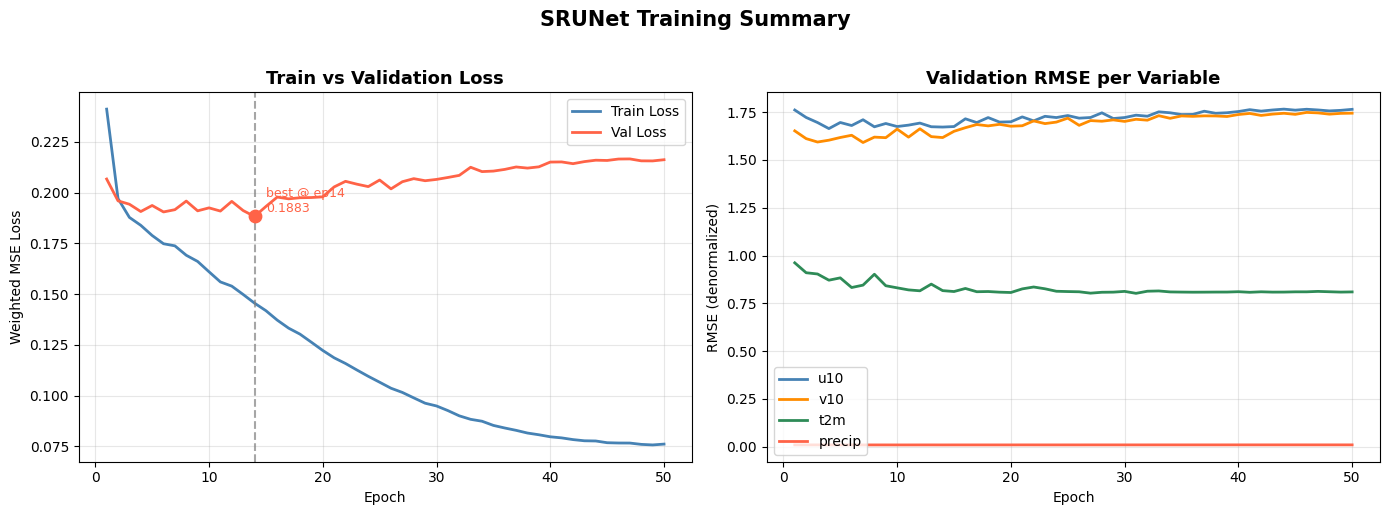

Saved → training_curves.png


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

# ── Left: Train vs Val Loss ──────────────────────
ax1 = axes[0]
ax1.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato",    linewidth=2)

# Mark best val loss
best_epoch = np.argmin(history["val_loss"]) + 1
best_loss  = min(history["val_loss"])
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 1, best_loss + 0.002),
    fontsize=9, color="tomato"
)

ax1.set_title("Train vs Validation Loss", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Weighted MSE Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# ── Right: Val Metrics over epochs ───────────────
ax2 = axes[1]
var_colors = {"u10": "steelblue", "v10": "darkorange", "t2m": "seagreen", "precip": "tomato"}

for var in vars_list:
    rmse_curve = [m[var]["RMSE"] for m in history["val_metrics"]]
    ax2.plot(epochs, rmse_curve, label=var, color=var_colors[var], linewidth=2)

ax2.set_title("Validation RMSE per Variable", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (denormalized)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("SRUNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")

/home/jovyan/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/jovyan/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/jovyan/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


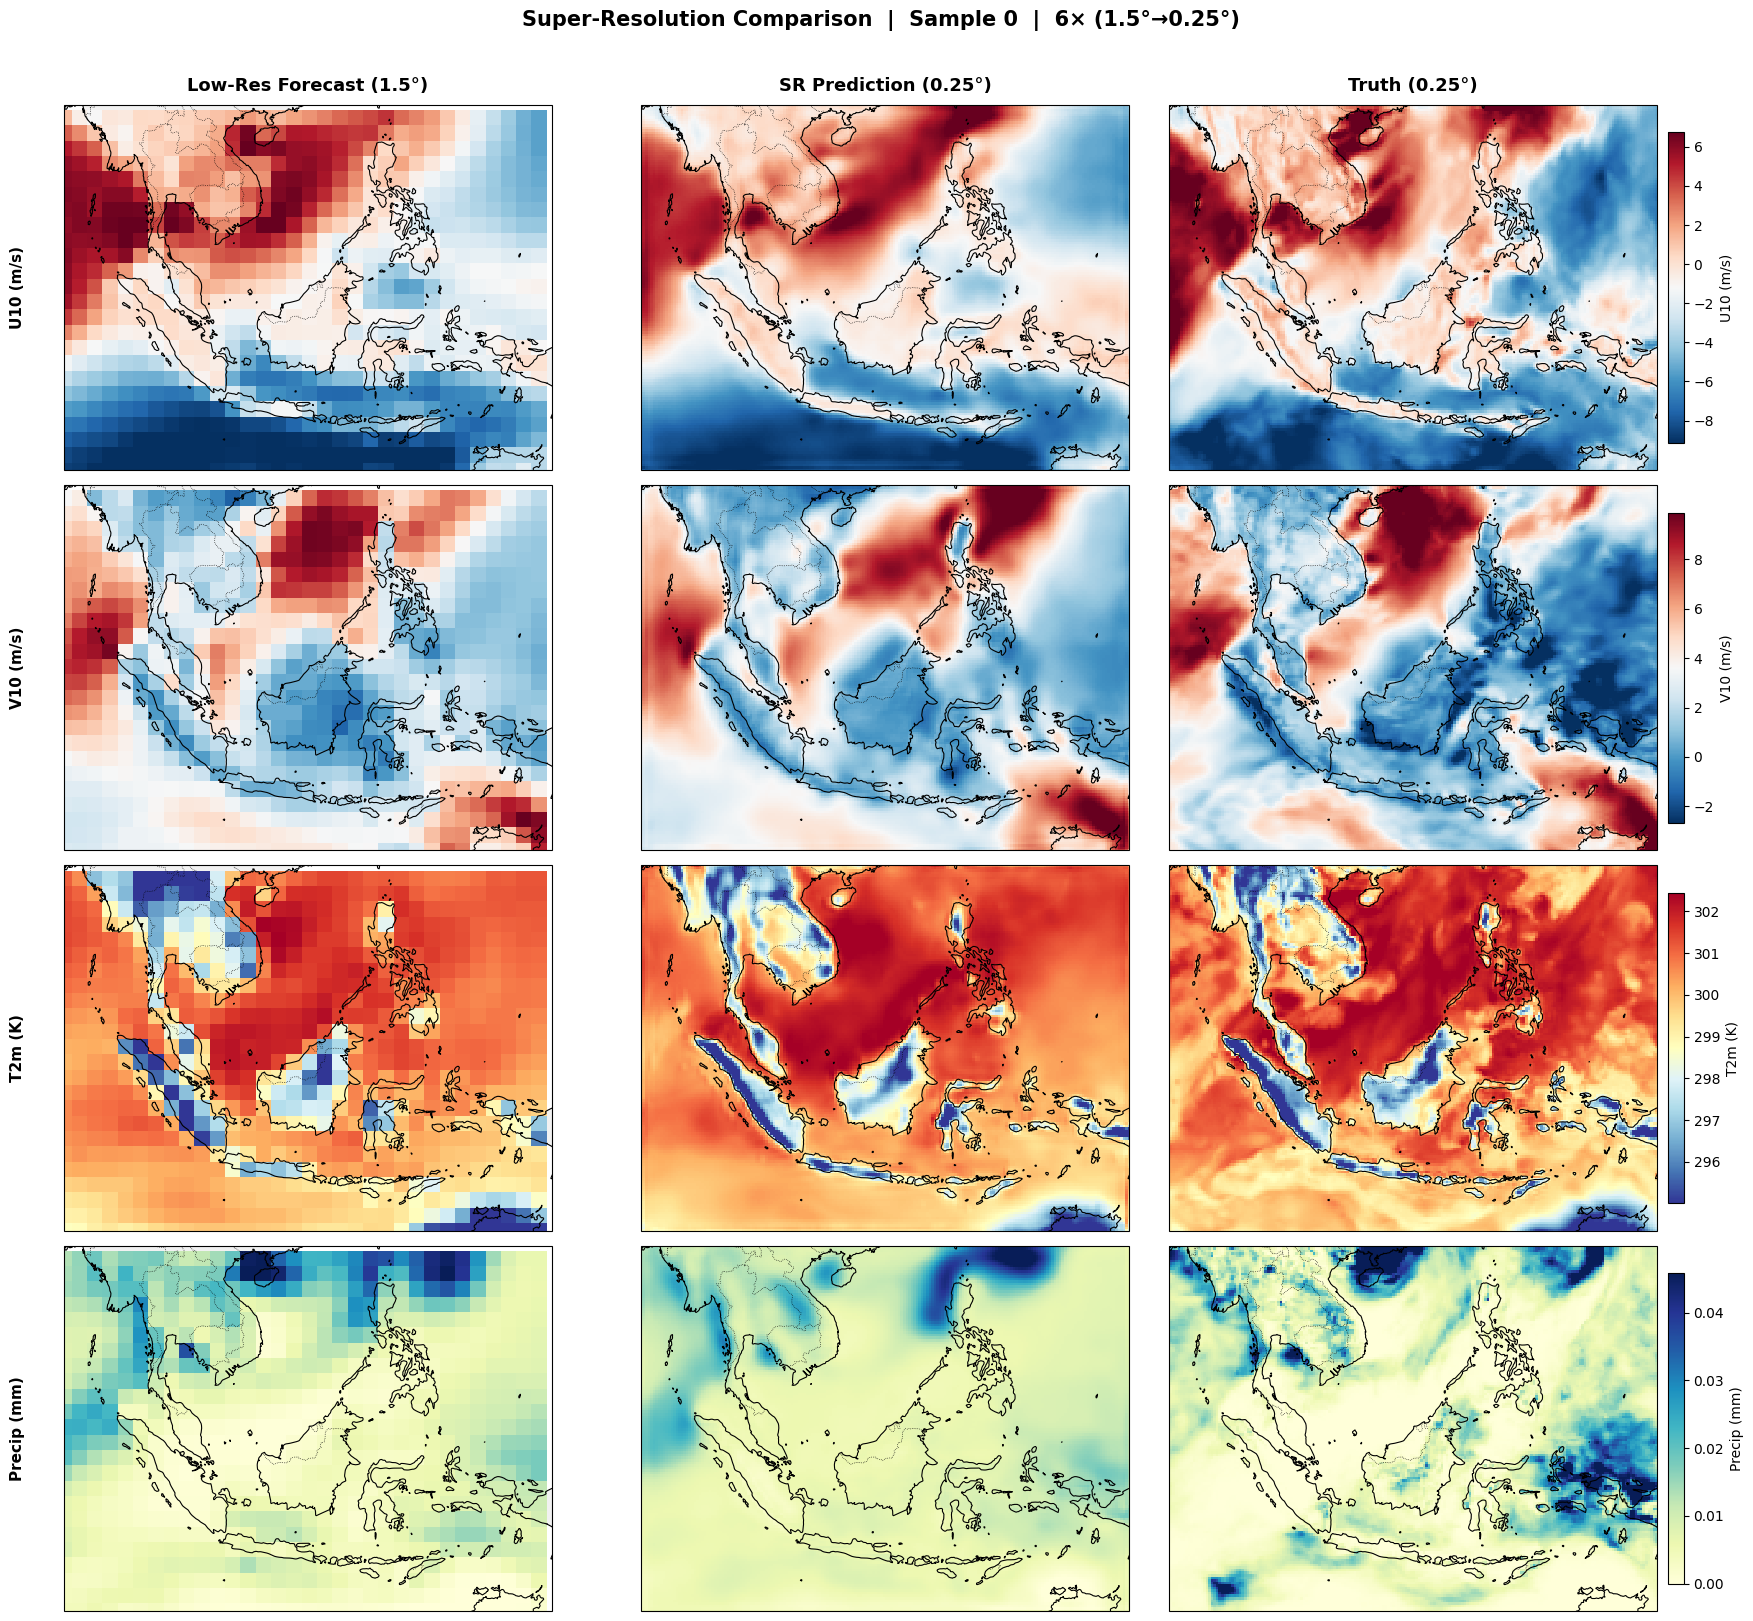

Saved → sr_map_comparison.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np

# ==========================================
# 1️⃣ Get one sample from test set
# ==========================================
model.eval()
device = next(model.parameters()).device

X_sample = X_test[[0]].to(device)   # (1, 4, 24, 32)
Y_sample = Y_test[[0]]               # (1, 4, 144, 192)  ground truth

with torch.no_grad():
    Y_pred = model(X_sample).cpu()   # (1, 4, 144, 192)  prediction

# Denormalize all
X_dn    = denormalize(X_sample.cpu(), norm_stats)[0]   # (4, 24,  32)
Y_true  = denormalize(Y_sample,       norm_stats)[0]   # (4, 144, 192)
Y_pred  = denormalize(Y_pred,         norm_stats)[0]   # (4, 144, 192)

# ==========================================
# 2️⃣ Coordinate arrays
# ==========================================
fc_lons = ds_fc.longitude.values        # (32,)  low-res
fc_lats = ds_fc.latitude.values         # (24,)
tr_lons = ds_tr.longitude.values        # (192,) high-res
tr_lats = ds_tr.latitude.values         # (144,)

# ==========================================
# 3️⃣ Plot config per variable
# ==========================================
var_cfg = {
    "10m_u_component_of_wind"    : {"label": "U10 (m/s)",    "cmap": "RdBu_r",  "idx": 0},
    "10m_v_component_of_wind"    : {"label": "V10 (m/s)",    "cmap": "RdBu_r",  "idx": 1},
    "2m_temperature"             : {"label": "T2m (K)",      "cmap": "RdYlBu_r","idx": 2},
    "total_precipitation_24hr"   : {"label": "Precip (mm)",  "cmap": "YlGnBu",  "idx": 3},
}

proj = ccrs.PlateCarree()

# ==========================================
# 4️⃣ Plot: 4 vars × 3 columns (LR / SR / Truth)
# ==========================================
n_vars = len(var_cfg)
fig, axes = plt.subplots(
    n_vars, 3,
    figsize=(18, n_vars * 4),
    subplot_kw={"projection": proj},
)

col_titles = ["Low-Res Forecast (1.5°)", "SR Prediction (0.25°)", "Truth (0.25°)"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=10)

for var, cfg in var_cfg.items():
    row = cfg["idx"]
    i   = cfg["idx"]

    lr_data = X_dn[i].numpy()     # (24,  32)
    sr_data = Y_pred[i].numpy()   # (144, 192)
    gt_data = Y_true[i].numpy()   # (144, 192)

    vmin = float(np.percentile(gt_data, 2))
    vmax = float(np.percentile(gt_data, 98))

    for col, (data, lons, lats) in enumerate([
        (lr_data, fc_lons, fc_lats),
        (sr_data, tr_lons, tr_lats),
        (gt_data, tr_lons, tr_lats),
    ]):
        ax = axes[row, col]
        ax.set_extent(
            [tr_lons[0], tr_lons[-1], tr_lats[0], tr_lats[-1]],
            crs=proj
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="lightgray", alpha=0.3)

        im = ax.pcolormesh(
            lons, lats, data.T,      # ✅ transpose here
            cmap=cfg["cmap"],
            vmin=vmin, vmax=vmax,
            transform=proj,
            shading="auto",          # ✅ and here
        )

        if col == 2:
            plt.colorbar(im, ax=ax, orientation="vertical",
                         label=cfg["label"], shrink=0.85, pad=0.02)

    axes[row, 0].text(
        -0.08, 0.5, cfg["label"],
        transform=axes[row, 0].transAxes,
        fontsize=11, fontweight="bold",
        va="center", ha="right", rotation=90,
    )

plt.suptitle(
    "Super-Resolution Comparison  |  Sample 0  |  6× (1.5°→0.25°)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("sr_map_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sr_map_comparison.png")